### Task 5 — A Real Time Series (flights.csv)

We will first load the dataset and combine the `year` and `month` columns into a proper datetime column to create a continuous time series axis.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/flights.csv')

# Combine year and month into a single datetime column
# We will assume the 1st of each month for completeness
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'] + '-01')
df = df.sort_values('date')

display(df.head())
print(df.info())

,year,month,passengers,date
0,1949,January,112,1949-01-01
1,1949,February,118,1949-02-01
2,1949,March,132,1949-03-01
3,1949,April,129,1949-04-01
4,1949,May,121,1949-05-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    int64         
 1   month       144 non-null    object        
 2   passengers  144 non-null    int64         
 3   date        144 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 4.6+ KB
None


#### Chart 1: Passenger Totals Over Time (Single Continuous Line)

This chart highlights the dual patterns: a long-term upward trend and a repeating annual seasonality.

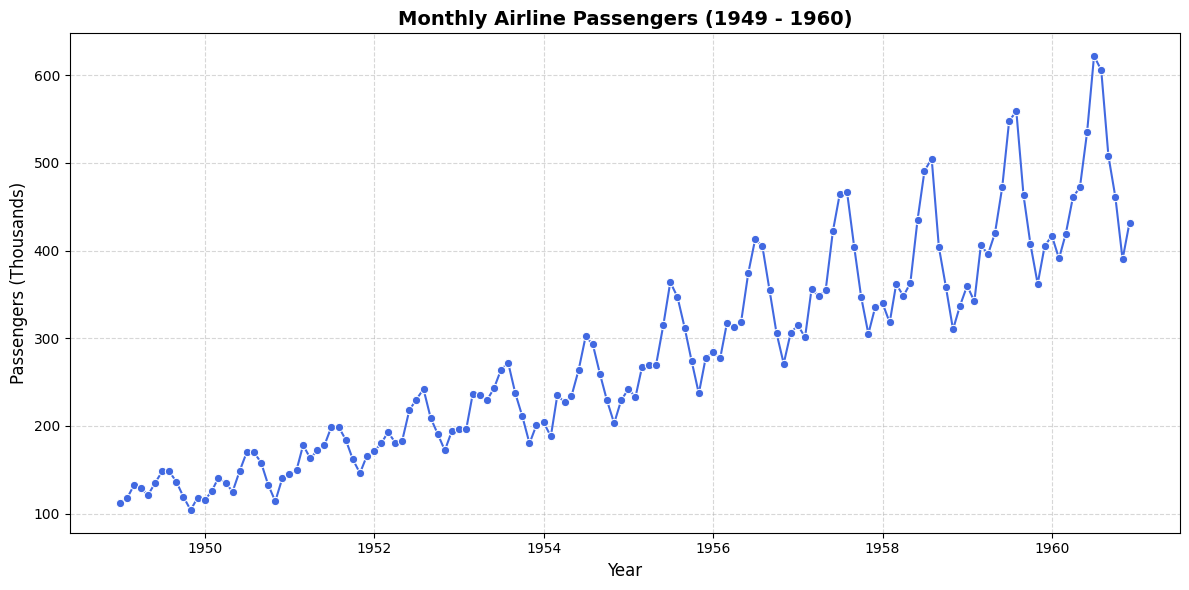

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='passengers', marker='o', color='royalblue')
plt.title('Monthly Airline Passengers (1949 - 1960)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Passengers (Thousands)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Chart 2: Isolated Seasonal Cycle (One Line Per Year)

To isolate the annual cycle, we plot the months on the X-axis and draw a separate line for each year.

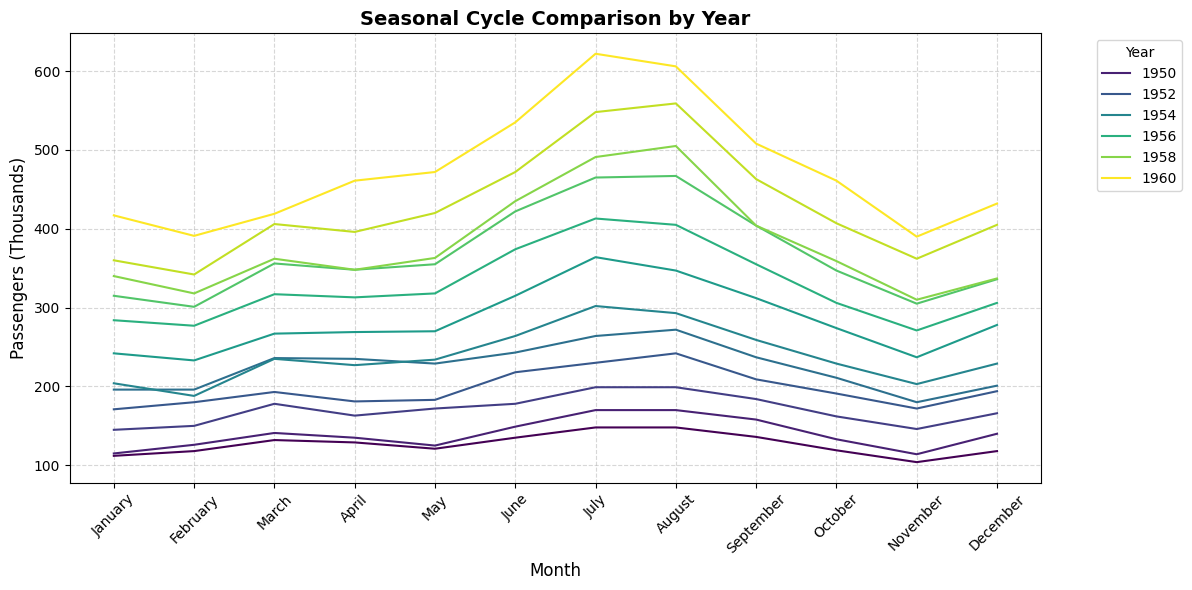

In [8]:
# Ensure month order is chronological for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x='month',
    y='passengers',
    hue='year',
    palette='viridis',
    sort=False
)
plt.title('Seasonal Cycle Comparison by Year', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Passengers (Thousands)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Chart 3: Identifying the Busiest Month

To make the busiest month instantly obvious, we can plot the average passenger count for each month across all years using a bar chart with highlighted colors.

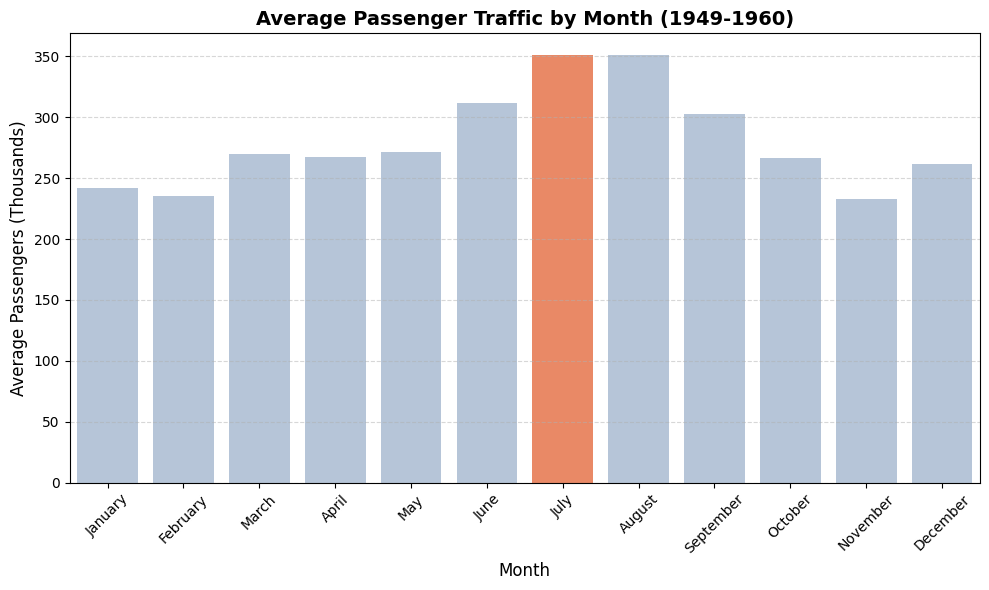

In [9]:
# Calculate mean passengers per month
monthly_avg = df.groupby('month')['passengers'].mean().reindex(month_order).reset_index()

# Identify the maximum value to highlight it
max_val = monthly_avg['passengers'].max()
colors = ['coral' if x == max_val else 'lightsteelblue' for x in monthly_avg['passengers']]

plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_avg, x='month', y='passengers', palette=colors, hue='month', legend=False)
plt.title('Average Passenger Traffic by Month (1949-1960)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Passengers (Thousands)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Written Analysis & Report Recommendations

#### 1. Which chart belongs in a business report?
I would include **Chart 1 (Continuous Line Chart)** in a general business report.
* **Why Chart 1?** It is the most comprehensive; it immediately tells the core business story — the airline is growing dramatically year-over-year, while also experiencing clear annual cycles.
* **Why not the others?**
  * **Chart 2** is too busy and cluttered for an executive summary, with 12 overlapping lines that are hard to distinguish individually.
  * **Chart 3** completely hides the growth of the company over the decade, showing only the static average demand distribution.

#### 2. The Growing Seasonal Swing: Seasonality or Overall Growth?
The seasonal swing gets visibly bigger in absolute numbers (e.g., the peaks in the later years are much taller than in the earlier years). This is a classic characteristic of **multiplicative seasonality** — as the overall business (the baseline volume) grows, the absolute swing scales proportionally.

**To settle this definitively:**
We can plot the **percentage change** relative to the yearly baseline or average rather than absolute numbers. If the yearly peak-to-trough percentage remains relatively constant over the years, the growing absolute swing is purely driven by the growth of the airline, not because seasonality itself is intensifying.

Let's plot this scaled relationship below.

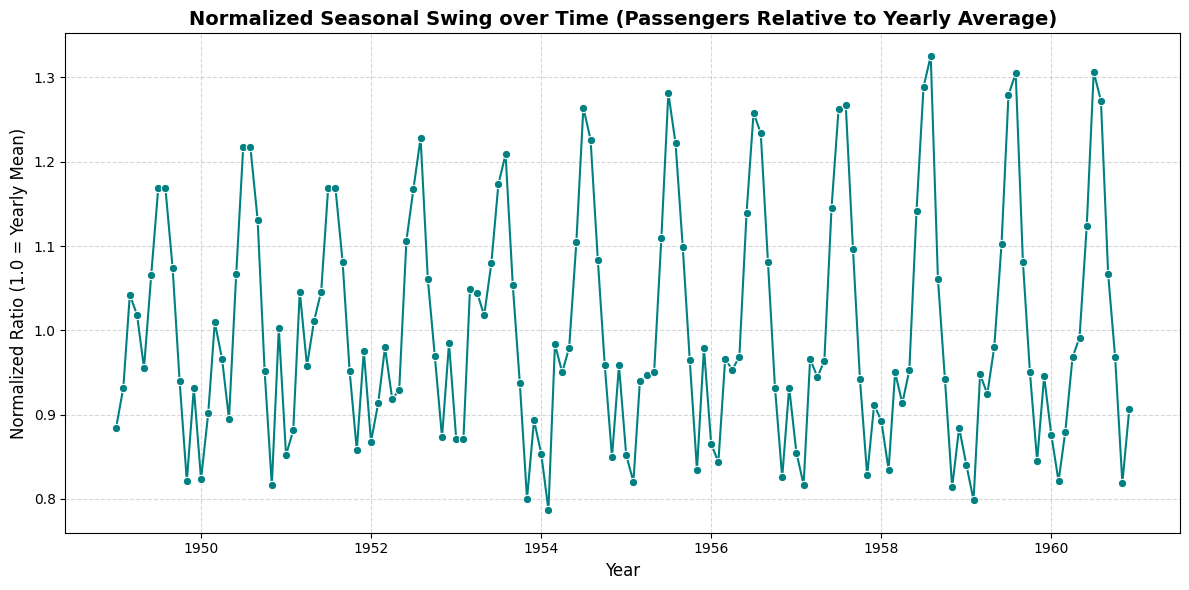

In [10]:
# Calculate yearly mean for each record
yearly_means = df.groupby('year')['passengers'].transform('mean')

# Normalize passengers by dividing by that year's mean (indexing seasonal behavior)
df['normalized_passengers'] = df['passengers'] / yearly_means

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='normalized_passengers', color='teal', marker='o')
plt.title('Normalized Seasonal Swing over Time (Passengers Relative to Yearly Average)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Normalized Ratio (1.0 = Yearly Mean)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()